# CNN with Batchnorm

- 3 convolutional blocks:
    - Conv2D → ReLU → MaxPooling
- Channel progression: 3 → 32 → 64 → 128

**Objective** <br/>
Evaluate whether adding Batch Normalization improves training stability and model performance.

**Changes from baseline** <br/>
- Added BatchNorm2d after each Conv2d layer
- Kept CNN architecture unchanged

**Hypothesis** <br/>
Batch Normalization will stabilize training, improve convergence, and lead to better generalization performance.

### 1. Import libraries

In [27]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.cnn_batchnorm import BatchNormCNN
from src.training.trainer import train_one_epoch, validate_one_epoch


from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

### 2. Use MPS

In [28]:
use_mps = True
print("MPS available:", torch.backends.mps.is_available())
device = torch.device("mps" if (use_mps and torch.backends.mps.is_available()) else "cpu")
print(f"Using device: {device}")

MPS available: True
Using device: mps


### 3. Split Dataset 
- Use batchNorm model
- Use BCEWithLogitsLoss
- Use Adam optimizer

In [29]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv="../../data/splits/train.csv",
    val_csv="../../data/splits/val.csv",
    test_csv="../../data/splits/test.csv",
    image_dir="../../data/raw/HAM10000/images",
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv("../../data/splits/train.csv")

num_melanoma = (train_df["label"] == 0).sum()  # CSV melanoma
num_nevus = (train_df["label"] == 1).sum()     # CSV nevus

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print("pos_weight:", pos_weight)

model = BatchNormCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

pos_weight: tensor([6.0244], device='mps:0')


### 4. Train Model

In [30]:
best_val_loss = float("inf")

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}"
    )

    # Save best model
    # if val_metrics["loss"] < best_val_loss:
    #     best_val_loss = val_metrics["loss"]
    #     torch.save(model.state_dict(), "../models/cnn_baseline.pth")
    #     print("Saved best model at epoch", epoch+1)

Epoch [1/20] | Train Loss: 4.7263, Train Acc: 0.6458 | Val Loss: 0.9288, Val Acc: 0.6633
Epoch [2/20] | Train Loss: 0.8651, Train Acc: 0.6407 | Val Loss: 0.8912, Val Acc: 0.6743
Epoch [3/20] | Train Loss: 0.8279, Train Acc: 0.6511 | Val Loss: 0.9045, Val Acc: 0.7818
Epoch [4/20] | Train Loss: 0.8337, Train Acc: 0.6628 | Val Loss: 0.9258, Val Acc: 0.6880
Epoch [5/20] | Train Loss: 0.8152, Train Acc: 0.6880 | Val Loss: 0.9064, Val Acc: 0.6692
Epoch [6/20] | Train Loss: 0.8375, Train Acc: 0.6771 | Val Loss: 0.8695, Val Acc: 0.6283
Epoch [7/20] | Train Loss: 0.8894, Train Acc: 0.7151 | Val Loss: 0.8305, Val Acc: 0.7025
Epoch [8/20] | Train Loss: 0.8381, Train Acc: 0.7050 | Val Loss: 0.7675, Val Acc: 0.7545
Epoch [9/20] | Train Loss: 0.8171, Train Acc: 0.7365 | Val Loss: 0.8201, Val Acc: 0.7349
Epoch [10/20] | Train Loss: 0.8259, Train Acc: 0.7317 | Val Loss: 0.9201, Val Acc: 0.6513
Epoch [11/20] | Train Loss: 0.8497, Train Acc: 0.7507 | Val Loss: 0.8880, Val Acc: 0.8048
Epoch [12/20] | Tra

### 5. Plot Loss and Accuracy Curves

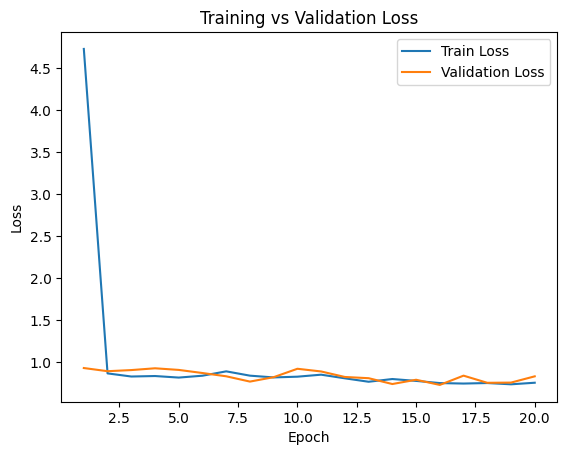

In [31]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

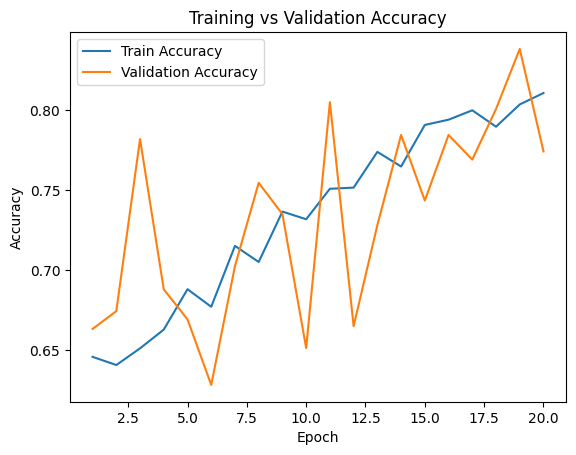

In [32]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### 6. Evaluate model
[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

Precision → “When the model says YES, how often is it correct?” <br/>
Recall → “Out of all actual YES, how many did we catch?”

In [33]:
from sklearn.metrics import f1_score, precision_score, recall_score, balanced_accuracy_score
import numpy as np

model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.05, 0.95, 0.05)

best_threshold = 0.5
best_f1 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    f1 = f1_score(val_labels, preds)

    print(
        f"Threshold={threshold:.2f} | "
        f"F1={f1:.4f} | "
        f"Precision={precision_score(val_labels, preds):.4f} | "
        f"Recall={recall_score(val_labels, preds):.4f} | "
        f"Balanced Acc={balanced_accuracy_score(val_labels, preds):.4f}"
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nBest threshold on validation set: {best_threshold:.2f}")


Threshold=0.05 | F1=0.3990 | Precision=0.2504 | Recall=0.9820 | Balanced Acc=0.7470
Threshold=0.10 | F1=0.4015 | Precision=0.2531 | Recall=0.9701 | Balanced Acc=0.7475
Threshold=0.15 | F1=0.4065 | Precision=0.2571 | Recall=0.9701 | Balanced Acc=0.7524
Threshold=0.20 | F1=0.4096 | Precision=0.2596 | Recall=0.9701 | Balanced Acc=0.7554
Threshold=0.25 | F1=0.4133 | Precision=0.2626 | Recall=0.9701 | Balanced Acc=0.7589
Threshold=0.30 | F1=0.4157 | Precision=0.2659 | Recall=0.9521 | Balanced Acc=0.7579
Threshold=0.35 | F1=0.4236 | Precision=0.2729 | Recall=0.9461 | Balanced Acc=0.7638
Threshold=0.40 | F1=0.4485 | Precision=0.3017 | Recall=0.8743 | Balanced Acc=0.7691
Threshold=0.45 | F1=0.4804 | Precision=0.3357 | Recall=0.8443 | Balanced Acc=0.7835
Threshold=0.50 | F1=0.5065 | Precision=0.3676 | Recall=0.8144 | Balanced Acc=0.7909
Threshold=0.55 | F1=0.5303 | Precision=0.4071 | Recall=0.7605 | Balanced Acc=0.7883
Threshold=0.60 | F1=0.5442 | Precision=0.4449 | Recall=0.7006 | Balanced Acc

#### 7. Balance

In [37]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= threshold).long()            # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [38]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[885 121]
 [ 59 108]]
              precision    recall  f1-score   support

           0     0.9375    0.8797    0.9077      1006
           1     0.4716    0.6467    0.5455       167

    accuracy                         0.8465      1173
   macro avg     0.7046    0.7632    0.7266      1173
weighted avg     0.8712    0.8465    0.8561      1173



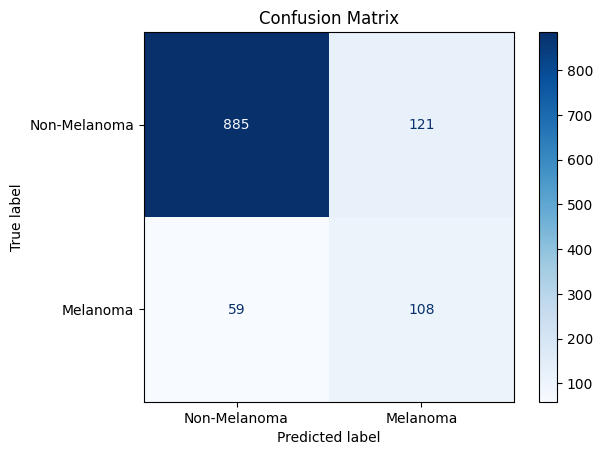

In [39]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

#### 8. What if we maximize melanoma recall

Confusion Matrix:
[[518 488]
 [  3 164]]
              precision    recall  f1-score   support

           0     0.9942    0.5149    0.6785      1006
           1     0.2515    0.9820    0.4005       167

    accuracy                         0.5814      1173
   macro avg     0.6229    0.7485    0.5395      1173
weighted avg     0.8885    0.5814    0.6389      1173



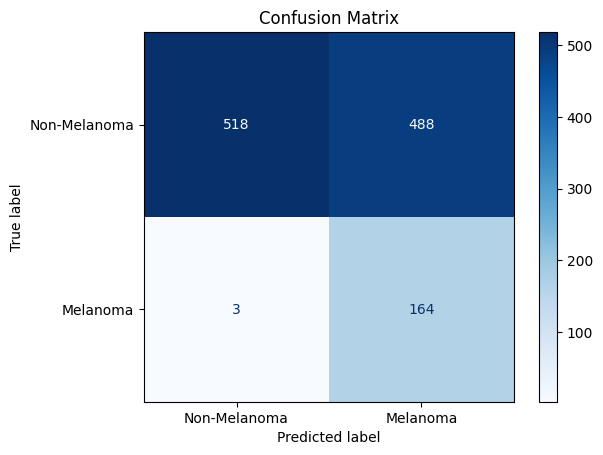

In [42]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = 0.05

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= threshold).long()            # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print(classification_report(all_labels, all_preds, digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

**BAD**

### Conculsion

Threshold **0.65** was selected because it maximized validation F1. <br/>
Lower thresholds such as 0.20 to 0.30 achieved higher melanoma recall, but at the cost of substantially lower precision.